# PyTorch Tutorial

## 1. Tensors

Tensors are a data structure similar to arrays and matrices.

__In PyTorch, tensors encode the inputs and outputs of a model, as well as the model's parameters.__

Tensors are similar to NumPy's ndarrays, except that tensors can run on GPUs (/hardware accelerators).

Tensors and NumPy arrays can often share the same underlying memory, removing the need to copy data.

Tensors are also optimised for __automatic differentiation__ (Autograd).

In [1]:
import torch
import numpy as np

### Initializing a Tensor

Tensors can be initialized in various ways:

__Directly from data__:

In [2]:
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)

__From a NumPy array__:

In [3]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

__From another tensor__:

In [4]:
# retains the properties of x_data:
x_ones = torch.ones_like(x_data)
print(f"Ones Tensor: \n {x_ones} \n")

# overrides the datatype of x_data:
x_rand = torch.rand_like(x_data, dtype = torch.float)
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.8113, 0.6036],
        [0.7471, 0.4042]]) 



__With random or constant values__:

'shape' is a tuple of tensor dimensions. In the functions below, it determines the dimensionality of the output tensor.

In [5]:
shape = (2, 3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor} \n")

Random Tensor: 
 tensor([[0.3353, 0.3520, 0.0541],
        [0.4198, 0.7505, 0.3390]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]]) 



### Attributes of a Tensor

Tensor attributes describe their shape, datatype, and the device on which they are stored.

In [6]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Operations on Tensors

There are over 1200 tensor operations, including arithmetic, linear algebra, matrix manipulation, and more.

Each of these operations can be run on the CPU, or an Accelerator such as CUDA.

By default, tensors are created on the CPU.

We need to explicitly move tensors to the accelerator using .to method, __after checking for accelerator availability__.

In [7]:
# Moving the tensor to the current accelerator, if available
if torch.accelerator.is_available():
    tensor = tensor.to(torch.accelerator.current_accelerator())

__Standard numpy-like indexing and slicing__:

In [8]:
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


__Joining tensors__

You can use torch.cat to concatenate a sequence of tensors along a given dimension.

There is also torch.stack

In [9]:
t1 = torch.cat([tensor, tensor, tensor], dim = 1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


__Arithmetic operations__

In [10]:
# Computing the matrix multiplication between two tensors.
# y1, y2, y3, will have the same value.
# 'tensor.T' returns the transpose of a tensor
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out = y3)

# The code above is 3 different ways to multiply tensors ^^^

# Computing the element-wise product.
# z1, z2, z3, will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out = z3)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

__Single-element tensors__ - if you have a one-element tensor, for example by aggregating all values of a tensor into one value, you can convert it to a Python numerical value using item()

In [11]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

12.0 <class 'float'>


__In-place operations__ - operations that store the result into the operand are called in-place.

They are denoted by a '_' suffix.

For example: x.copy_(y), x.t_() will change x.

In [12]:
print(f"{tensor} \n")
tensor.add_(5)
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


In-place operations save memory but cause problems when computing derivatives due to the immediate loss of memory. Their use is discouraged.

### Bridge with NumPy

Tensors on the CPU and NumPy arrays can share their underlying memory locations, and changing one will change the other.

### Tensor to NumPy array

In [13]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


A change in the tensor can be seen in the NumPy array

In [14]:
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


### NumPy array to Tensor

In [15]:
n = np.ones(5)
t = torch.from_numpy(n)

Changes in the NumPy array show changes in the tensor

In [16]:
np.add(n, 1, out = n)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


## Datasets & DataLoaders

As code for processing data samples can get messy, PyTorch separates dataset code from model training code.

PyTorch provides two data primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset`, that allow you to use pre-loaded datasets as well as your own data.

`Dataset` stores the samples and labels, and `DataLoader` wraps an iterable around the `Dataset` to enable easy access of the samples.

PyTorch domain libraries have a number of pre-loaded datasets, such as FashionMNIST, that subclass `torch.utils.data.Dataset` and implement functions specific to that data.

They can be used to prototype and benchmark your model.

### Loading a Dataset

This example will load the FashionMNIST dataset from TorchVision. It consists of 60,000 training examples and 10,000 test examples. Each example is a 28x28 grayscale image and an associated label from one of 10 classes.

We can load the FashionMNIST Dataset with the following parameters:
- `root` is the path where the train/test data is stored
- `train` specifies training or test dataset
- `download=True` downloads the data from the internet if it's not available at `root`
- `transform` and `target_transform` specify the feature and label transformations

In [17]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.7MB/s]


### Iterating and Visualising the Dataset

We can index `Datasets` manually like a list: `training_data[index]`. We use `matplotlib` to visualise some samples in our training data.

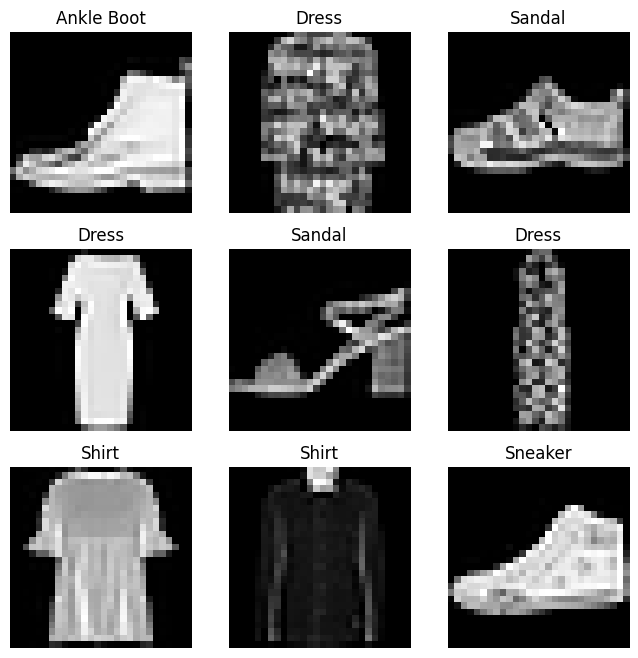

In [18]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Creating a Custom Dataset for your files

A custom Dataset class must implement three functions: `__init__`, `__len__`, and `__getitem__`.

In this implementation, the FashionMNIST images are stored in a directory `img_dir`, and their labels are stored separately in a CSV file `annotations_file`.

In [19]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
  def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
    self.img_labels = pd.read_csv(annotations_file)
    self.img_dir = img_dir
    self.transform = transform
    self.target_transform = target_transform

def __len__(self):
  return len(self.img_labels)

def __getitem__(self, idx):
  img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
  image = decode_image(img_path)
  label = self.img_labels.iloc[idx, 1]
  if self.transform:
    image = self.transform(image)
  if self.target_transform:
    label = self.target_transform(label)
  return image, label

### `__init__`

The `__init__` function is run once when instantiating the Dataset object. We initialise the directory containing the images, the annotations file, and both transforms.

The labels.csv file looks like:

tshirt1.jpg, 0

tshirt2.jpg, 0

......

ankleboot999.jpg, 9

In [20]:
def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
  self.img_labels = pd.read_csv(annotations_file)
  self.img_dir = img_dir
  self.transform = transform
  self.target_transform = target_transform

### `__len__`

The `__len__` function returns the number of samples in our dataset.

In [21]:
def __len__(self):
    return len(self.img_labels)

### `__getitem__`

The `__getitem__` function loads and returns a sample from the dataset at the given index `idx`.

Based on the index, it identifies the image's location on disk, converts that to a tensor using `decode_image`, retrieves the corresponding label from the csv data in `self.img_labels`, calls the transform functions on them, and returns the tensor image and corresponding label in a tuple.

In [22]:
def __getitem__(self, idx):
    img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
    image = decode_image(img_path)
    label = self.img_labels.iloc[idx, 1]
    if self.transform:
        image = self.transform(image)
    if self.target_transform:
        label = self.target_transform(label)
    return image, label

### Preparing your data for training with DataLoaders

The `Dataset` retrieves our dataset's features and labels one sample at a time. While training the model, we typically want to pass samples in 'minibatches', reshuffle the data at every epoch to reduce model overfitting, and use Python's `multiprocessing` to speed up data retrieval.

`DataLoader` is an iterable that removes this complexity, in an easy API.

In [23]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

### Iterate through the DataLoader

We have loaded that dataset into the `DataLoader` and can iterate through the dataset as needed.

Each iteration below returns ta batch of `train_features` and `train_labels` (containing `batch_size=64` features and labels respectively).

Because we specified `shuffle=True`, after we iterate over all batches the data is shuffled.

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


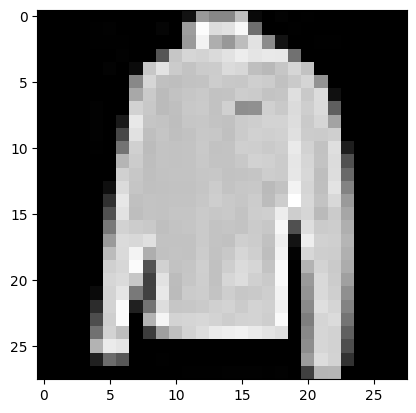

Label: 4


In [24]:
# displaying images and label
train_features, train_labels = next(iter(train_dataloader))

print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

img = train_features[0].squeeze()
label = train_labels[0]

plt.imshow(img, cmap="gray")
plt.show()

print(f"Label: {label}")

## Transforms

Data does not always come in its final processed form that is required for training machine learning algorithms. We use transforms to perform some manipulation of the data and make it suitable for training.

All TorchVision datasets have two parameters - `transform` to modify the features and `target_transform` to modify the labels - that accept callables containing the transformation logic. The torchvision.transforms module offers several commonly-used transforms out of the box.

The FashionMNIST features are in PIL Image format, and the labels are integers. For training, we need the features as normalised tensors, and the labels as one-hot encoded tensors. To make these transformations, we use `ToTensor` and `Lambda`.

In [25]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

### ToTensor()

ToTensor converts a PIL image or NumPy `ndarry` into a `FloatTensor` and scales the image's pixel intensity values in the range [0, 1].

### Lambda Transforms

Lambda transforms apply any unser-defined lambda function. Here, we define a function to turn the integer into a one-hot encoded tensor.

It first creates a zero tensor of size 10 (the number of labels in our dataset) and calls `scatter_` which assigns a `value=1` on the index as given by the label `y`.

In [26]:
target_transform = Lambda(lambda y: torch.zeros(
    10, dtype=torch.float).scatter_(dim=0, index=torch.tensor(y), value=1))

## Build the Neural Network

Neural networks comprise of layers/modules that perform operations on data.

The `torch.nn` namespace provides all the building blocks needed to build a neural network.

Every module in PyTorch subclasses the `nn.Module`.

A neural network is a module itself that consists of other modules (layers). This nested structure allows for building and managing complex architectures easily.

This section will build a neural network to classify images in the FashionMNIST dataset.

In [27]:
import os
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Get Device for Training

We want to be able to train our model on an accelerator such as CUDA or XPU. If the current accelerator is available, we will use it. Otherwise, we will use the CPU.

On Google Colab you can change runtime to T4 GPU.

In [28]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### Define the Class

We define our neural network by subclassing `nn.Module`, and initialise the neural network layers in `__init__`. Every `nn.Module` subclass implements the operations on input data in the `forward` method.

Think of `__init__` as laying out the Lego pieces, and `forward` being where you construct them in the right order.

In [29]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10),
    )

    def forward(self, x):
      x = self.flatten(x)
      logits = self.linear_relu_stack(x)
      return logits

We create an instance of `NeuralNetwork`, and move it to the `device`, and print its structure.

In [30]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


To use the model, we need to pass it the input data. This executes the model's `forward`, along with some background operations. Do not call `model.forward()` directly.

Calling the model on the input returns a 2-dimensional tensor with dim=0 corresponding to each output of 10 raw predicted values for each class, and dim=1 corresponding to the individual values of each output. We get the prediction probabilities by passing it through an instance of the `nn.Softmax` module.

In [32]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

NotImplementedError: Module [NeuralNetwork] is missing the required "forward" function

### Model Layers

Breaking down the layers in the FashionMNIST model. To illustrate it, will take a sample minibatch of 3 images of size 28x28 and see what happens as we pass it through the layers of the network.

In [ ]:
input_image = torch.rand(3,28,28)
print(input_image.size())

### nn.Flatten

We initialize the nn.Flatten layer to convert each 2D 28x28 image into a contiguous array of 784 pixel values. The minibatch dimension at dim=0 is maintained.

In [ ]:
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

### nn.Linear

The linear layer is a module that applies a linear transformation on the input using its stored weights and biases.

In [ ]:
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

### nn.ReLU

Non-linear activations are what create the complex mappings between the model's inputs and outputs. They are applied after linear transformations to introduce nonlinearity, helping neural networks learn a wide variety of phenomena.

In this model, we use nn.ReLU between our linear layers, but there's other activations to introduce non-linearity in your model.

In [ ]:
print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

### nn.Sequential

nn.Sequential is an ordered container of modules. The data is passed through all the modules in the same order as defined. You can use sequential containers to put together a quick network like `seq_modules`.

In [ ]:
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)
input_image = torch.rand(3,28,28)
logits = seq_modules(input_image)

### nn.Softmax

The last linear layer of the neural network returns 'logits' - raw values in [-infty, infty] - which are passed to the nn.Softmax module. The logits are scaled to values [0, 1], representing the model's predicted probabilities for each class.

`dim` parameter indicates the dimension along which the values must sum to 1.

In [ ]:
softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)

### Model Parameters

Many layers inside a neural network are parameterised, ie they have associated weights and biases that are optimised during training.

Subclassing `nn.Module` automatically tracks all fields defined inside your model object, and makes all parameters accessible using your model's `parameters()` or `named_parameters()` methods.

In this example, we iterate over each parameter, and print its size and a preview of its values.

In [ ]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

## Automatic Differentiation with `torch.autograd`

While training neural networks, the most frequently used algorithm is back propagation. In this algorithm, parameters (model weights) are adjusted according to the gradient of the loss function with respect to the given parameter.

To compute those gradients, PyTorch has a built-in differentiation engine called `torch.autograd`. It supports automatic computation of gradient for any computational graph.

Consider the simplest one-layer neural network, with input x, parameters w and b, and some loss function. It can be defined in PyTorch in the following manner:

In [ ]:
import torch

x = torch.ones(5) # input tensor
y = torch.zeros(3) # expected output
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w) + b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

## Tensors, Functions, and Computational Graph

This code defines the following computational graph:

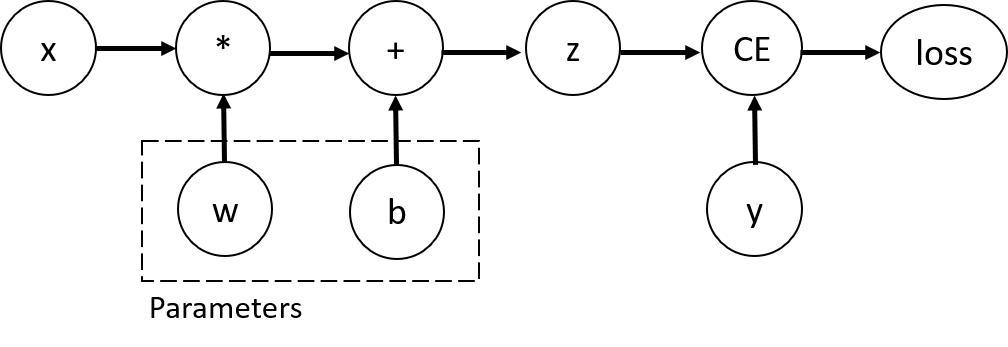

In this network, w and b are parameters, which we need to optimise. Thus, we need to be able to compute the gradients of loss function with respect to those variables. In order to do that, we set the `requires grad` property to one of those tensors.

A function that we apply to tensors to construct computational graph is in fact an object of class `Function`. This object knows how to compute the function in the forward direction, and also how to compute its derivative during the backward propagation step.

A reference to the backward propagation function is stored in the `grad_fn` property of a tensor.

In [ ]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

### Computing Gradients

To optimise weights of parameters in the neural network, we need to compute the derivatives of our loss function with respect to parameters.

Namely, we need dLoss/dW and dLoss/dB, under some fixed values of x and y.

To compute those derivatives, we call `loss.backward()` and then retrieve the values from `w.grad` and `b.grad`:

In [ ]:
loss.backward()
print(w.grad)
print(w.grad)

### Disabling Gradient Tracking

By default, all tensors with `requires_grad=True` are tracking their computational history and support gradient computation.

However, there are some cases when we do not need to do that, for example, when we have trained the model and just want to apply it to some input data, ie we only want to do forward computations through the network. We can stop tracking computations by surrounding our computation code with a `torch.no_grad()` block:

In [ ]:
z = torch.matmul(x, w)+b
print(z.requires_grad)

with torch.no_grad():
  z = torch.matmul(x, w)+b
print(z.requires_grad)

Another way to achieve the same result is to use the `detach()` method on the tensor:

In [ ]:
z = torch.matmul(x, w)+b
z_det = z.detach()
print(z_det.requires_grad)

Reasons you might want to disable gradient tracking:

- To mark some parameters in your neural network as frozen parameters

- To speed up computations when you are only doing the forward pass, because computations on tensors that do not track gradients would be more efficient

### More on Computational Graphs

Conceptually, autograd keeps a record of data (tensors) and all executed operations (along with the resulting new tensors) in a directed acyclic graph (DAG) consisting of `Function` objects.

In this DAG, leaves are the input tensors, roots are the output tensors. By tracing this graph from roots to leaves, you can automatically compute the gradients using the chain rule.

In a forward pass, autograd does two things simultaneously:

- Run the requested operation to compute a resulting tensor

- Maintain the operation's gradient function in the DAG

The backward pass kicks off when `.backward()` is called on the DAG root. `autograd` then:

- Computes the gradients from each `.grad_fn`

- Accumulates them in the respective tensor's `.grad` attribute

- Using the chain rule, propagates all the way to the leaf tensors

### Tensor Gradients and Jacobian Products

In many cases we have a scalar loss function and need to compute the gradient with respect to some parameters. However, there are cases when the output function is an arbitrary tensor. In this case, PyTorch allows you to compute a __Jacobian product__, and not the actual gradient.

For a vector function y = f(x), where x = (x1, ...., xn) and y = (y1, ...., yn), a gradient of y with respect to x is given by a __Jacobian matrix__:

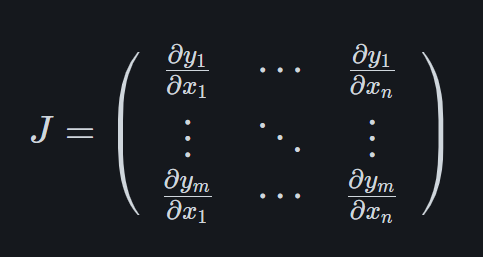

Instead of computing the Jacobian matrix itself, PyTorch allows you to compute __Jacobian Product__ vT x J for a given input vector v = (v1 ... vm).

This is achieved by calling `backward` with v as an argument. The size of v should be the same as the size of the original tensor, with respect to which we want to compute the product:

In [ ]:
inp = torch.eye(4, 5, requires_grad=True)
out = (inp+1).pow(2).t()
out.backward(torch.ones_like(out), retain_graph=True)
print(f"First call\n{inp.grad}")
out.backward(torch.ones_like(out), retain_graph=True)
print(f"\nSecond call\n{inp.grad}")
inp.grad.zero_()
out.backward(torch.ones_like(out), retain_graph=True)
print(f"\nCall after zeroing gradients\n{inp.grad}")

Notice that when `backward` is called the second time with the same argument, the value of the gradient is different. This happens because when doing `backward` propagation, PyTorch __accumulates the gradients__, ie the value of computed gradients is added to the `grad` property of all leaf nodes of computational graph.

If you want to compute the proper gradients, you need to zero out the `grad` property before. In real-life training an optimiser helps you do this.

## Optimising Model Parameters

Now that we have a model and data, it's time to train, validate, and test our model by optimising its parameters on our data.

Training a model is an iterative process; in each iteration the model:

- Makes a guess about the output,

- Calculates the error in its guess (_loss_),

- Collects the derivatives of the error with respect to its parameters,

- And __optimises__ these parameters using gradient descent.

### Prerequisite Code

From Datasets and DataLoaders and Build Model sections

In [33]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

### Hyperparameters

Hyperparameters are adjustable parameters that let you control the model optimisation process. Different hyperparameter values can impact model training and convergence rates.

We define the following hyperparameters for training:

- __Number of Epochs__ - the number of times to iterate over the dataset

- __Batch Size__ - the number of data samples propagated through the network before the parameters are updated

- __Learning Rate__ - how much to update models parameters at each batch/epoch. Smaller values yield slow learning speed, while large values may result in unpredictable behaviour during training.

In [34]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

### Optimisation Loop

Once we set our hyperparameters, we can then train and optimise our model with an optimisation loop. Each iteration of the optimisation loop is called an __epoch__.

Each epoch consists of two main parts:

- __The Train Loop__ - iterate over the training dataset and try to converge to optimal parameters.

- __The Validation/Test Loop__ - iterate over the test dataset to check if model performance is improving.

### Loss Function

When presented with some training data, our untrained network is likely not to give the correct answer.

Loss function measures the degree of dissimilarity of obtained results to the target value, and it is the loss function that we want to minimise during training.

To calculate the loss we make a prediction using the inputs of our given data sample and compare it against the true data label value.

Common loss functions include `nn.MSELoss` (Mean Square Error) for regression tasks, and `nn.NLLLoss` (Negative Loss Likelihood) for classification. `nn.CrossEntropyLoss` combines `nn.LogSoftmax` and `nn.NLLLoss`.

We pass our model's output logits to `nn.CrossEntropyLoss`, which will normalise the logits and compute the prediction error.

In [35]:
# initialising the loss function
loss_fn = nn.CrossEntropyLoss()

### Optimizer

Optimisation is the process of adjusting model parameters to reduce model error in each training step. Optimisation algorithms define how this process is performed - in this example using Stochastic Gradient Descent. All optimisation logic is encapsulated in the `optimizer` object. Here, we use the SGD optimizer, but there are many others too.

We initialise the optimiser by registering the model's parameters that need to be trained, and passing in the learning rate hyperparameter.

In [36]:
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

Inside the training loop, optimization happens in three steps:

*   Call `optimizer.zero_grad() to reset the gradients of model parameters. Gradients by default add up - to prevent double-counting, we explicitly zero them at each iteration
*   Backpropagate the prediction loss with a call to `loss.Backward()`. PyTorch deposits the gradients of the loss w.r.t each parameter.
*  Once we have our gradients, we call `optimizer.step()` to adjust the parameters by the gradients collected in their backward pass.



### Full Implementation

We define `train_loop` that loops over our optimisation code, and `test_loop` that evaluates the model's performance against our test data.

In [37]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

We initialise the loss function and optimiser, and pass it to `train_loop` and `test_loop`.

In [38]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.309762  [   64/60000]
loss: 2.288846  [ 6464/60000]
loss: 2.265505  [12864/60000]
loss: 2.251966  [19264/60000]
loss: 2.240086  [25664/60000]
loss: 2.208396  [32064/60000]
loss: 2.218272  [38464/60000]
loss: 2.183403  [44864/60000]
loss: 2.179476  [51264/60000]
loss: 2.136955  [57664/60000]
Test Error: 
 Accuracy: 41.5%, Avg loss: 2.135836 

Epoch 2
-------------------------------
loss: 2.148286  [   64/60000]
loss: 2.133424  [ 6464/60000]
loss: 2.065819  [12864/60000]
loss: 2.083884  [19264/60000]
loss: 2.028935  [25664/60000]
loss: 1.967324  [32064/60000]
loss: 1.998357  [38464/60000]
loss: 1.912727  [44864/60000]
loss: 1.915288  [51264/60000]
loss: 1.840213  [57664/60000]
Test Error: 
 Accuracy: 56.5%, Avg loss: 1.840877 

Epoch 3
-------------------------------
loss: 1.869878  [   64/60000]
loss: 1.840291  [ 6464/60000]
loss: 1.717355  [12864/60000]
loss: 1.766656  [19264/60000]
loss: 1.651112  [25664/60000]
loss: 1.610853  [32064/600

## Quickstart

### Working with data

PyTorch has two primitives to work with data:

- torch.utils.data.DataLoader
- torch.utils.data.Dataset

'Dataset' stores the samples and their corresponding labels, and 'DataLoader' wraps an iterable around the 'Dataset'.

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

PyTorch has domain-specific libraries like TorchText, TorchVision, and TorchAudio, and they all include datasets.

This tutorial will use a TorchVision dataset.

The torchvision.datasets module contains Dataset objects for many real-world vision data.

Tutorial will use the FashionMNIST dataset.

Every TorchVision Dataset includes two arguments:
- transform
- target_transform

To modify the samples and labels respectively.

In [ ]:
# Downloading training data from open datasets
training_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor(),
)

# Downloading test data from open datasets
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
)

We pass the Dataset as an argument to DataLoader.

This wraps an iterable over our dataset, and supports automatic batching, sampling, shuffling, and multiprocess data loading.

Here we will define a batch size of 64; each element in the dataloader iterable will return a batch of 64 features and labels

In [ ]:
batch_size = 64

# Creating data loaders
train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

### Creating Models

To define a neural network in PyTorch, we create a class that inherits from nn.Module.

We define the layers of the network in the '\_\_init__' function and specify how data will pass through the network in the 'forward' function.

To accelerate operations in the neural network, we move it to the accelerator, such as CUDA or XPU. If the current accelerator is available, we use it. Otherwise, we use the CPU.

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Defining model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

### Optimizing the Model Parameters

To train a model, we need a loss function and an optimizer

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

In a single training loop, the model makes predictions on the training dataset - fed to it in batches - and then backpropagates the prediction error to adjust the model's parameters.

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Computing prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")